Created by Sean Harvey, mathematics educator expanding into data science and analytics.

The data used in this notebook came from the UCI Student Performance dataset, specifically math performance.

*   List item
*   List item



## 1. Executive Summary

  This project analyzes student performance data to identify early indicators of academic risk. Using exploratory analytics and predictive modeling, the goal is to help schools intervene sooner. Key drivers included prior failures, absences, and study time. A logistic regression model was used for interpretability, with a random forest used for comparison.

## 2. Business Problem

Schools often identify struggling students after final grades are posted. Earlier detection allows tutoring, counseling, attendance outreach, and schedule adjustments.

## 3. Dataset Overview

395 Pieces of data, 33 Features, For this project, final grade was converted to pass/fail target.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#Load data from Excel
df = pd.read_excel('student-mat.xlsx')


#Take a look at the data
print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


## 4. Data Cleaning and Preparation

### 4.1 Data Quality Checks

After confirming there were no missing values, data quality checks were performed to validate logical ranges and inspect unusual numeric values. Potential outliers, especially in absences, were reviewed but retained when they represented plausible student behavior rather than data-entry errors. A binary pass/fail target was then created from the final grade, and categorical variables were encoded for modeling. The target distribution was moderately imbalanced, with about 67% passes and 33% fails. Because of this, model evaluation focused not only on accuracy but also on recall, precision, and F1-score. Recall was especially important because missing an at-risk student is more costly than incorrectly flagging a student for additional support.

In [2]:
#Check basic info and missing values

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

No missing values, but we need to check for outliers, duplicates, and other errors that could affect models.

In [3]:
#Summary stats
#Check for unusual values in each of the columns

df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


Only notable value that seems to stand out is the number of absences which is between zero and seventy. From my research of Portugal their schooling follows a similar length to ours and should have over 180 student days. Seventy is over a third of the days absent. This will be further explored below this cell but also in the EDA portion of this notebook.

In [4]:
#Check ranges for key numeric columns

print("Age range:", df["age"].min(), "to", df["age"].max())

print("Absences range:", df["absences"].min(), "to", df["absences"].max())

print("Failures range:", df["failures"].min(), "to", df["failures"].max())

print("G1 range:", df["G1"].min(), "to", df["G1"].max())

print("G2 range:", df["G2"].min(), "to", df["G2"].max())

print("G3 range:", df["G3"].min(), "to", df["G3"].max())

Age range: 15 to 22
Absences range: 0 to 75
Failures range: 0 to 3
G1 range: 3 to 19
G2 range: 0 to 19
G3 range: 0 to 20


Again the only one that stands out is Absences, G1, G2, and G3 are out of 20 due to Portuguese grading systems.

In [5]:
#Check categorical values

print("\nCategorical columns:")

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    print(f"\n{col}:")

    print(df[col].value_counts())


Categorical columns:

school:
school
GP    349
MS     46
Name: count, dtype: int64

sex:
sex
F    208
M    187
Name: count, dtype: int64

address:
address
U    307
R     88
Name: count, dtype: int64

famsize:
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus:
Pstatus
T    354
A     41
Name: count, dtype: int64

Mjob:
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob:
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason:
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian:
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

schoolsup:
schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup:
famsup
yes    242
no     153
Name: count, dtype: int64

paid:
paid
no     214
yes    181
Name: count, dtype: int64

activities:
activities
yes    201
no   

Imbalance within classes can lead to models focusing on them to a greater degree. For more advanced modelling we might consider using a subset of the data where the classes are more balanced or create synthetic data that balances out the classes.

<Axes: xlabel='absences'>

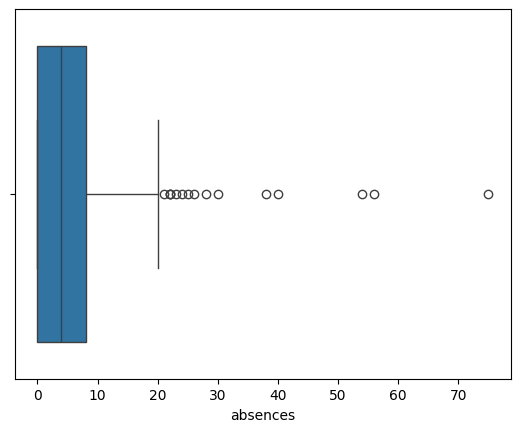

In [6]:
#Check for Outliers in absences
sns.boxplot(x=df['absences'])

It's clear that these values are outliers but students exist who have that many outliers. These students may be the exact ones we are looking to predict for. I am not going to remove these pieces of data from the dataset. I am going to check the other numerical features next.

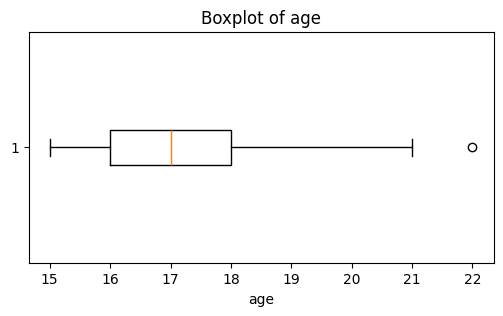

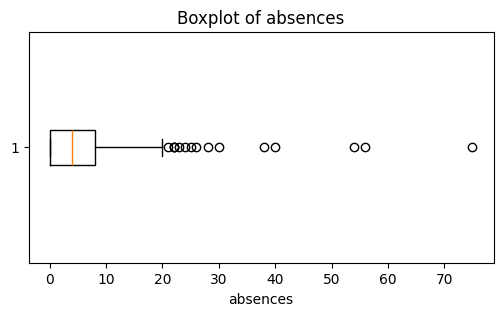

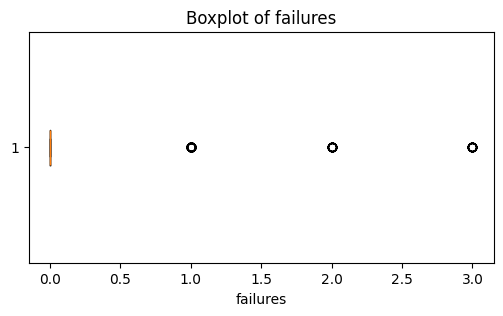

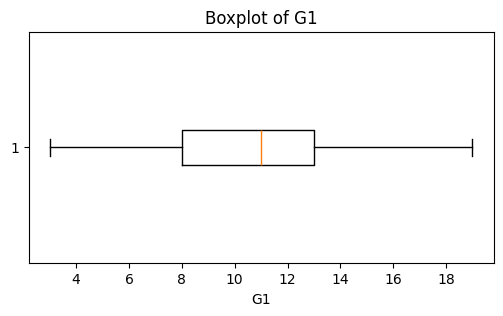

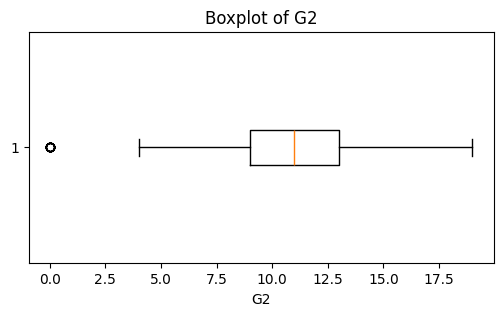

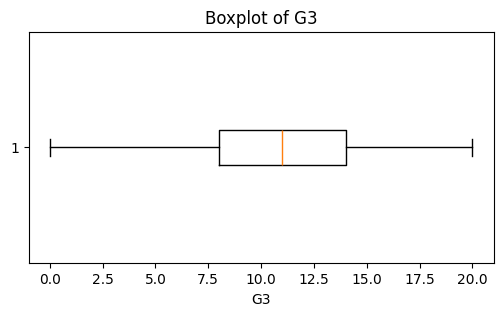

In [7]:
numeric_cols = ["age", "absences", "failures", "G1", "G2", "G3"]

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [8]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return lower, upper, outliers

for col in ["age", "absences", "G1", "G2", "G3"]:
    lower, upper, outliers = iqr_outliers(df[col])
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, n_outliers={len(outliers)}")

age: lower=13.00, upper=21.00, n_outliers=1
absences: lower=-12.00, upper=20.00, n_outliers=15
G1: lower=0.50, upper=20.50, n_outliers=0
G2: lower=3.00, upper=19.00, n_outliers=13
G3: lower=-1.00, upper=23.00, n_outliers=0


There are many outliers throughout the data but none that make me want to eliminate the data points. In education these would be the first people I take a closer look at to determine if they needed additional help.

## 4.2 Target Variable Creation

To align with the goal of identifying academically at-risk students, the final grade (G3) was converted into a binary outcome:

- Pass = Final grade of 10 or higher
- Fail = Final grade below 10

This transformation converts the problem into a classification task suitable for predictive modeling.

Alternative targets could include GPA bands, dropout risk, or regression on final grade. Pass/fail was selected for interpretability and intervention use cases.

In [9]:
#Data set is based in Portugal where they pass with a 10 - 20

df['pass']=df['G3'].apply(lambda x: 'pass' if x>=10 else 'fail')

In [10]:
#Check for Class Imbalance in Target
df['pass'].value_counts(normalize=True)

,proportion
pass,
pass,0.670886
fail,0.329114


There is a slight class imbalance but this is to be expected in education. This fail rate feels high to me. If we needed this for more advanced models we could make some synthetic data using a GAN but for this project we will analyze the given data.

## 4.3 Encoding Categorical Features

Categorical variables need to be encoded so they can be input into models.

In [11]:
df["pass"] = (df["G3"] >= 10).astype(int)

In [12]:
#Double check
df["pass"]

,pass
0,0
1,0
2,1
3,1
4,1
...,...
390,0
391,1
392,0
393,1


In [13]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)
print(df_encoded.head())

(395, 43)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes

I am planning on splitting the Variables into two models with the same Target. Model 1 trained on X1 will include G1 and G2 data but Model 2 trained on X2 will not include these because they are highly correlated and could bias the model too much.

In [14]:
X1 = df_encoded.drop(columns=["G3", "pass"])
X2 = df_encoded.drop(columns=["G1","G2","G3","pass"])
y = df_encoded["pass"]

## 4.4 Train/Test Split

Split the data into training and testing.

In [15]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train target distribution:")
print(y_train1.value_counts(normalize=True))

Train target distribution:
pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64


In [16]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train target distribution:")
print(y_train2.value_counts(normalize=True))

Train target distribution:
pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis

The following section explores relationships between student characteristics and academic outcomes to identify meaningful patterns before modeling.

### 5.1 Target Distribution

Below is the countplot of the Pass Fail, even though we showed this earlier by looking at the percentages of classes but this graphic is helpful for stakeholders to show the moderate class imbalance.

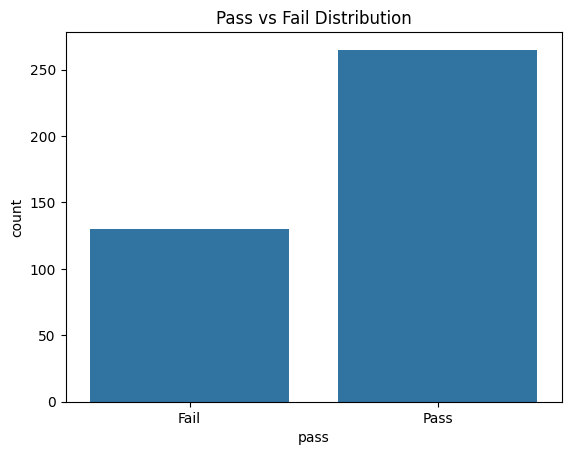

In [17]:
sns.countplot(x='pass', data=df)
plt.title("Pass vs Fail Distribution")
plt.xticks([0,1], ["Fail","Pass"])
plt.show()

Below we look at the individual breakdown of number of failures a student has had in the past compared to their current G3 pass or fail. Students who have never failed a class are less likely to fail the current class students who have failed a class in the past are more likely to fail a class in the future.

### 5.2 Prior Failures vs Pass Rate

In [18]:
pd.crosstab(df["failures"], df["pass"], normalize="index")

pass,0,1
failures,,
0,0.250000,0.750000
1,0.520000,0.480000
2,0.823529,0.176471
3,0.750000,0.250000


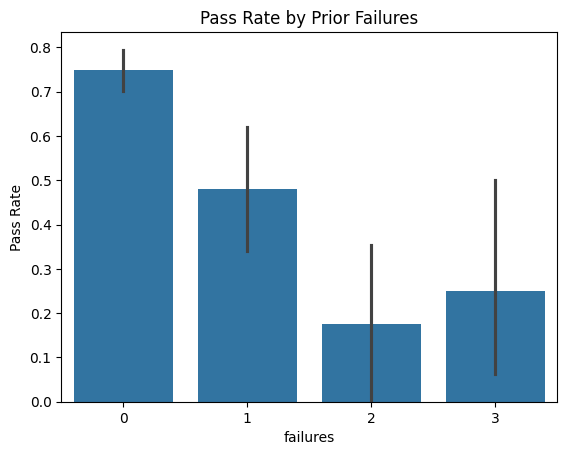

In [19]:
sns.barplot(x="failures", y="pass", data=df)
plt.title("Pass Rate by Prior Failures")
plt.ylabel("Pass Rate")
plt.show()

### 5.3 Absences vs Outcome

I looked at the pass rate based on the number of absences they have. There was no clear relationship between pass rates and absences which could require some further investigation probably on a student by student basis.

In [20]:
pd.crosstab(df["absences"], df["pass"], normalize="index")

pass,0,1
absences,,
0,0.434783,0.565217
1,0.000000,1.000000
2,0.184615,0.815385
3,0.250000,0.750000
4,0.226415,0.773585
5,0.600000,0.400000
6,0.193548,0.806452
7,0.428571,0.571429
8,0.272727,0.727273


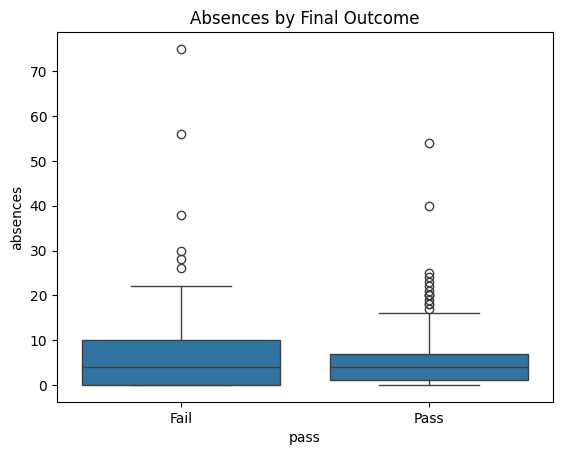

In [21]:
sns.boxplot(x="pass", y="absences", data=df)
plt.xticks([0,1], ["Fail","Pass"])
plt.title("Absences by Final Outcome")
plt.show()

### 5.4 Study Time vs Success

I then looked at the pass rate by how many hours they work on a weekly basis. Looking at the graphs, there is a slight uptick in passing once students are study 3 or 4 hours a day.

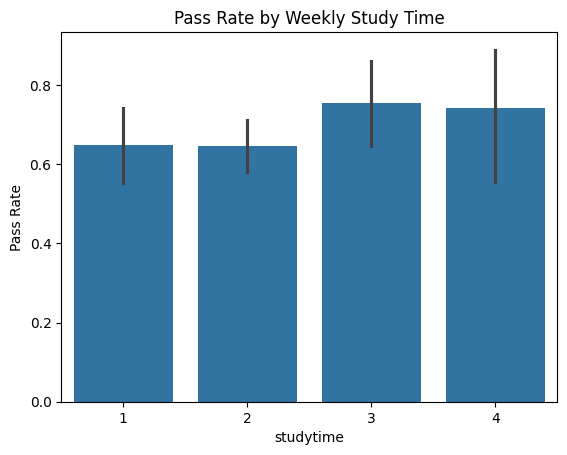

In [22]:
sns.barplot(x="studytime", y="pass", data=df)
plt.title("Pass Rate by Weekly Study Time")
plt.ylabel("Pass Rate")
plt.show()

### 5.5 Support Systems

In this section I looked at whether there was a correlation between passing and having school supports, internet, and family support. School support is an interesting one because student's getting School Supports might indicate that they have a higher overall chance of failure from the start hence the students without supports are more likely to pass than the students with supports. There is a slightly higher rate of passing for students who have access to the internet we could look at the number of students from the sample and run a hypothesis test to determine whether it was statistically significant. Looking at family support, I'd need further information of what that entails and why a family would be classified as support, at first glance it seems like having family support can be a detriment but that 'support' could mean that the family is getting support or the family is giving support.

In [23]:
pd.crosstab(df["schoolsup"], df["pass"], normalize="index")

pass,0,1
schoolsup,,
no,0.311047,0.688953
yes,0.450980,0.549020


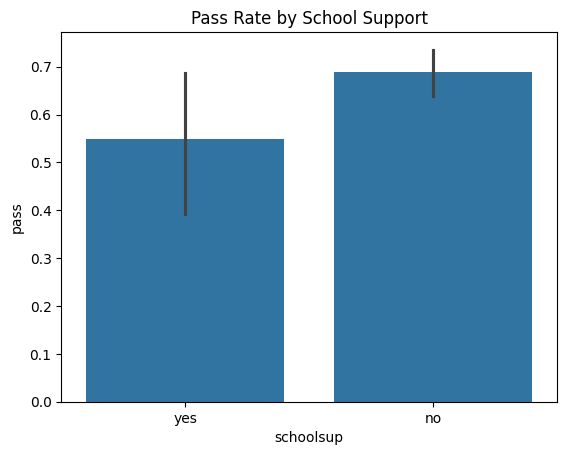

In [24]:
sns.barplot(x="schoolsup", y="pass", data=df)
plt.title("Pass Rate by School Support")
plt.show()

In [25]:
pd.crosstab(df["internet"], df["pass"], normalize="index")

pass,0,1
internet,,
no,0.393939,0.606061
yes,0.316109,0.683891


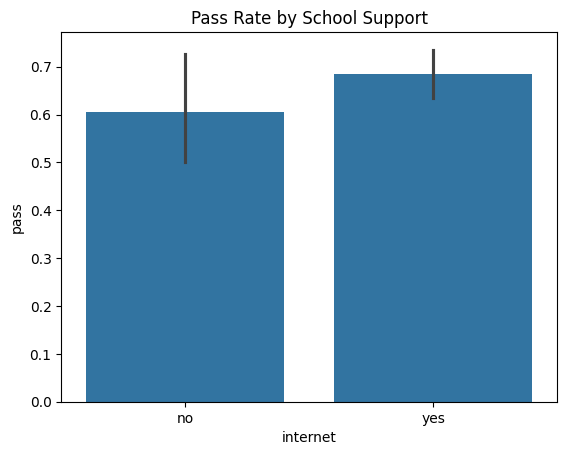

In [26]:
sns.barplot(x="internet", y="pass", data=df)
plt.title("Pass Rate by School Support")
plt.show()

In [27]:
pd.crosstab(df["famsup"], df["pass"], normalize="index")

pass,0,1
famsup,,
no,0.294118,0.705882
yes,0.351240,0.648760


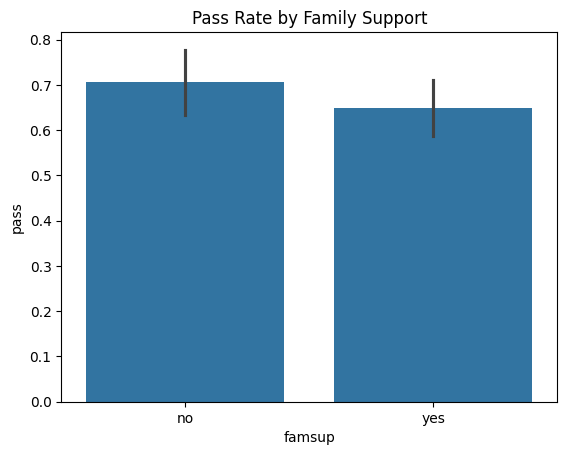

In [28]:
sns.barplot(x="famsup", y="pass", data=df)
plt.title("Pass Rate by Family Support")
plt.show()

### 5.6 Correlation Heatmap

In this section I look at all the correlatinos between all the variables, the interesting thing is not that the G1 and G2 scores correlate to G3 score, that is to be expected but the rate at which past failues is negativley correlated with their pass rate. Overall though there are many variables that aren't linearly correlated with passing, that doesn't mean that they don't contribute but their contribution is not linear.

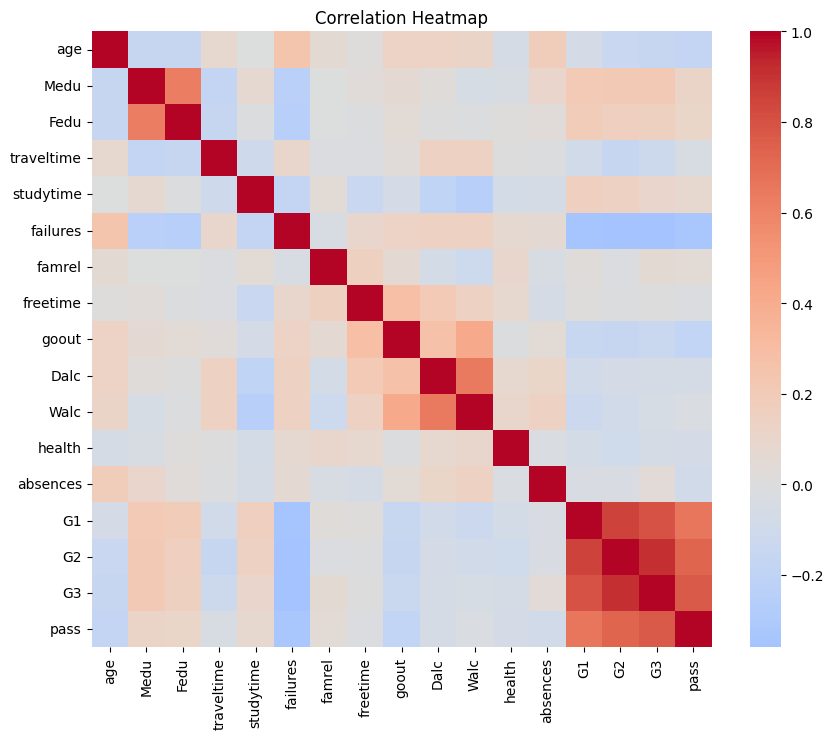

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 6. Predictive Modeling: Logistic Regression

Logistic Regression was selected as the initial model because it is interpretable, efficient, and well-suited for binary classification problems such as predicting pass/fail outcomes.

For educational settings, interpretability is especially valuable because stakeholders may want to understand why a student is being flagged as at-risk rather than only receiving a prediction.


In [30]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    roc_auc_score,

    RocCurveDisplay

)

# Create model

log_model1 = LogisticRegression(max_iter=2000)
log_model2 = LogisticRegression(max_iter=2000)

# Train model

log_model1.fit(X_train1, y_train1)
log_model2.fit(X_train2, y_train2)

# Predictions

y_pred1 = log_model1.predict(X_test1)
y_pred2 = log_model2.predict(X_test2)
y_prob1 = log_model1.predict_proba(X_test1)[:,1]
y_prob2 = log_model2.predict_proba(X_test2)[:,1]

In [31]:
print("Accuracy:", round(accuracy_score(y_test1, y_pred1),3))
print("Precision:", round(precision_score(y_test1, y_pred1),3))
print("Recall:", round(recall_score(y_test1, y_pred1),3))
print("F1 Score:", round(f1_score(y_test1, y_pred1),3))
print("ROC AUC:", round(roc_auc_score(y_test1, y_prob1),3))

Accuracy: 0.886
Precision: 0.958
Recall: 0.868
F1 Score: 0.911
ROC AUC: 0.967


In [32]:
print("Accuracy:", round(accuracy_score(y_test2, y_pred2),3))
print("Precision:", round(precision_score(y_test2, y_pred2),3))
print("Recall:", round(recall_score(y_test2, y_pred2),3))
print("F1 Score:", round(f1_score(y_test2, y_pred2),3))
print("ROC AUC:", round(roc_auc_score(y_test2, y_prob2),3))

Accuracy: 0.658
Precision: 0.717
Recall: 0.811
F1 Score: 0.761
ROC AUC: 0.592


Looking at both logistic models we note that the first model, which includes the G1 and G2 grades is more accurate but accuracy is not the best statistics for determinig usefulness. This speaks to the idea that G1 and G2 are highly correlated with G3, they might even be used in the calculation of the Final Grade as is the case in many high schools. When G1 and G2 are removed the accuracy drops 23%. The good thing about both of these models is the high recall rate. This means that we are identifying most students who are going to fail prior to failing our second model only is about 5% worse in recall but both have over an 80% prediction rate.  

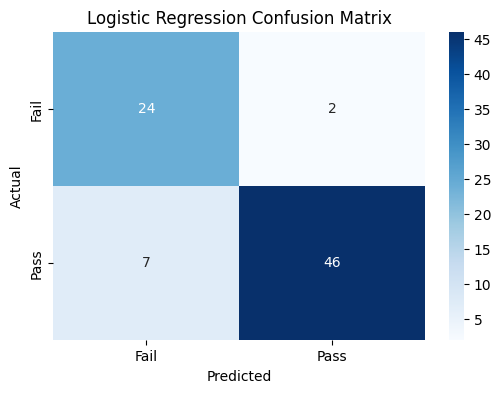

In [33]:
cm1 = confusion_matrix(y_test1, y_pred1)

plt.figure(figsize=(6,4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fail","Pass"],
            yticklabels=["Fail","Pass"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

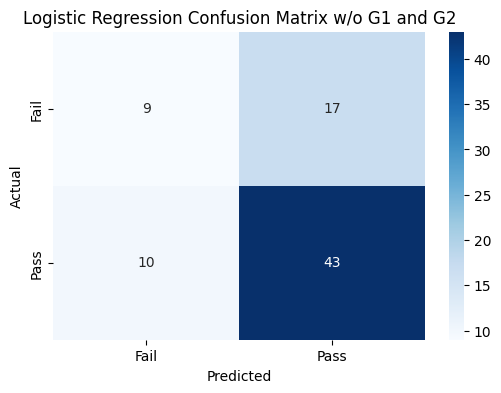

In [34]:
cm2 = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fail","Pass"],
            yticklabels=["Fail","Pass"])
plt.title("Logistic Regression Confusion Matrix w/o G1 and G2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Model Performance Summary

The Logistic Regression model provided a strong and interpretable baseline for identifying academically at-risk students.

Recall was an especially important metric in this project because failing to identify a struggling student may be more costly than incorrectly flagging a student for additional support.

In [35]:
coef_df1 = pd.DataFrame({
    "Feature": X_train1.columns,
    "Coefficient": log_model1.coef_[0]
})

coef_df1["Abs_Coefficient"] = coef_df1["Coefficient"].abs()
coef_df1 = coef_df1.sort_values("Abs_Coefficient", ascending=False)

coef_df1.head(10)

,Feature,Coefficient,Abs_Coefficient
14,G2,2.189770,2.189770
15,school_MS,1.130018,1.130018
25,Fjob_other,1.100927,1.100927
16,sex_M,-0.932169,0.932169
18,famsize_LE3,-0.863039,0.863039
6,famrel,0.805502,0.805502
10,Walc,0.795429,0.795429
33,schoolsup_yes,-0.719065,0.719065
0,age,-0.577642,0.577642
36,activities_yes,-0.551510,0.551510


In [36]:
coef_df2 = pd.DataFrame({
    "Feature": X_train2.columns,
    "Coefficient": log_model2.coef_[0]
})

coef_df2["Abs_Coefficient"] = coef_df2["Coefficient"].abs()
coef_df2 = coef_df2.sort_values("Abs_Coefficient", ascending=False)

coef_df2.head(10)

,Feature,Coefficient,Abs_Coefficient
5,failures,-1.239859,1.239859
21,Mjob_teacher,-0.900156,0.900156
31,schoolsup_yes,-0.875942,0.875942
36,higher_yes,0.726561,0.726561
18,Mjob_health,0.632577,0.632577
17,Pstatus_T,-0.510593,0.510593
20,Mjob_services,0.495184,0.495184
30,guardian_other,-0.494155,0.494155
35,nursery_yes,-0.467140,0.467140
8,goout,-0.460670,0.460670


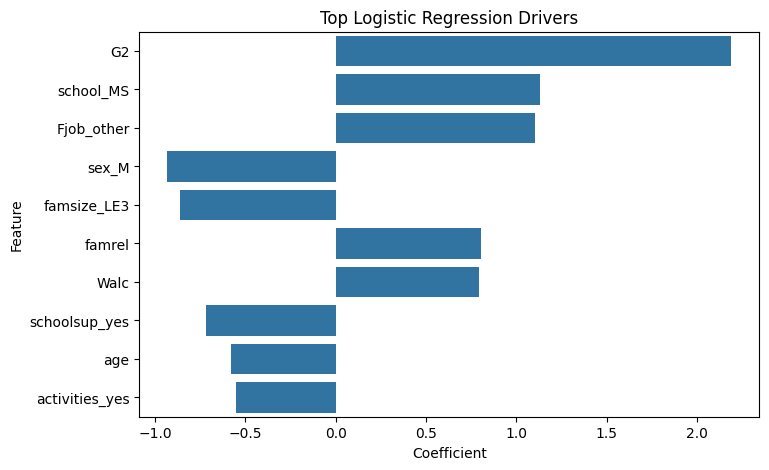

In [37]:
top = coef_df1.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top, x="Coefficient", y="Feature")
plt.title("Top Logistic Regression Drivers")
plt.show()

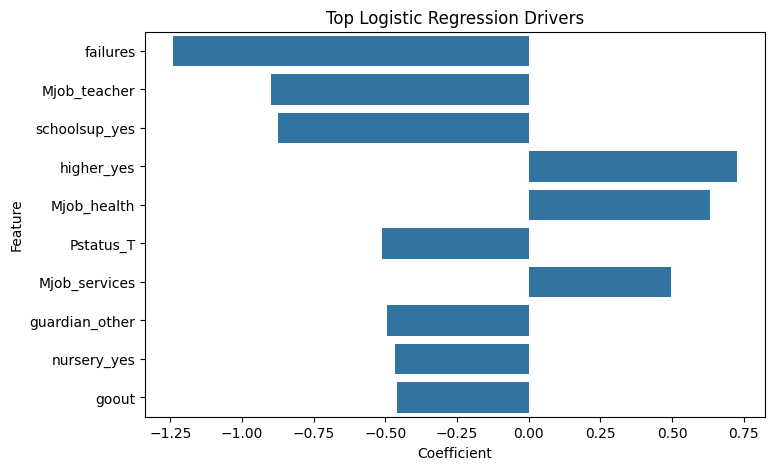

In [38]:
top = coef_df2.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top, x="Coefficient", y="Feature")
plt.title("Top Logistic Regression Drivers")
plt.show()

Positive coefficients increased the likelihood of passing, while negative coefficients were associated with higher academic risk.

Prior failures and absences were associated with higher academic risk, while stronger prior grades increased the likelihood of passing.

This helps stakeholders understand not only predictions, but which factors may be contributing to student outcomes.

## 7. Predictive Modeling: Random Forest

Random Forest was selected as a second model because it can capture nonlinear relationships and interactions between variables while reducing overfitting through ensemble learning.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model1.fit(X_train1, y_train1)

rf_pred1 = rf_model1.predict(X_test1)
rf_prob1 = rf_model1.predict_proba(X_test1)[:,1]

In [40]:
print("Accuracy:", round(accuracy_score(y_test1, rf_pred1),3))
print("Precision:", round(precision_score(y_test1, rf_pred1),3))
print("Recall:", round(recall_score(y_test1, rf_pred1),3))
print("F1:", round(f1_score(y_test1, rf_pred1),3))
print("ROC AUC:", round(roc_auc_score(y_test1, rf_prob1),3))

Accuracy: 0.873
Precision: 0.957
Recall: 0.849
F1: 0.9
ROC AUC: 0.942


In [41]:
rf_importance1 = pd.DataFrame({
    "Feature": X_train1.columns,
    "Importance": rf_model1.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance1.head(10)

,Feature,Importance
14,G2,0.383407
13,G1,0.242806
5,failures,0.054540
12,absences,0.035813
8,goout,0.023607
0,age,0.020466
10,Walc,0.015593
11,health,0.013684
2,Fedu,0.013521
1,Medu,0.012892


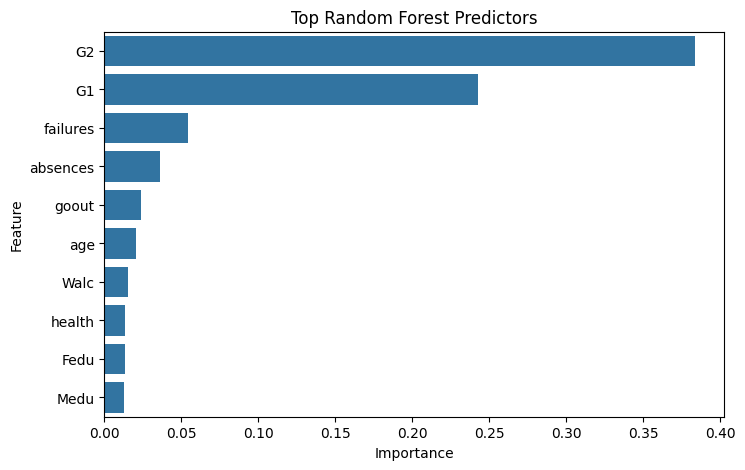

In [42]:
top = rf_importance1.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top, x="Importance", y="Feature")
plt.title("Top Random Forest Predictors")
plt.show()

In [43]:
rf_model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model2.fit(X_train2, y_train2)

rf_pred2 = rf_model2.predict(X_test2)
rf_prob2 = rf_model2.predict_proba(X_test2)[:,1]

In [44]:
print("Accuracy:", round(accuracy_score(y_test2, rf_pred2),3))
print("Precision:", round(precision_score(y_test2, rf_pred2),3))
print("Recall:", round(recall_score(y_test2, rf_pred2),3))
print("F1:", round(f1_score(y_test2, rf_pred2),3))
print("ROC AUC:", round(roc_auc_score(y_test2, rf_prob2),3))

Accuracy: 0.671
Precision: 0.701
Recall: 0.887
F1: 0.783
ROC AUC: 0.635


In [45]:
rf_importance2 = pd.DataFrame({
    "Feature": X_train2.columns,
    "Importance": rf_model2.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance2.head(10)

,Feature,Importance
5,failures,0.129250
12,absences,0.104870
8,goout,0.061746
0,age,0.053413
10,Walc,0.039582
2,Fedu,0.037971
11,health,0.036076
7,freetime,0.035305
1,Medu,0.035294
6,famrel,0.033687


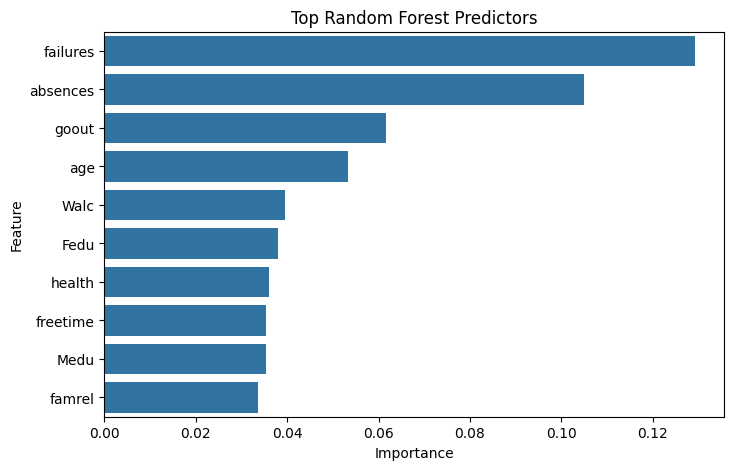

In [46]:
top = rf_importance2.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top, x="Importance", y="Feature")
plt.title("Top Random Forest Predictors")
plt.show()

In [47]:
results = pd.DataFrame({
    "Model": ["Logistic Regression (w/ G1,G2)", "Random Forest (w/ G1,G2)", "Logistic Regression (w/o G1,G2)", "Random Forest (w/o G1,G2)"],
    "Accuracy": [0.886, 0.873, 0.658, 0.671],
    "Precision": [0.958, 0.957, 0.717, 0.701],
    "Recall": [0.868, 0.849, 0.811, 0.887],
    "F1": [0.911, 0.9, 0.761, 0.783],
    "ROC AUC": [0.967, 0.942, 0.592, 0.635]
})
results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,"Logistic Regression (w/ G1,G2)",0.886,0.958,0.868,0.911,0.967
1,"Random Forest (w/ G1,G2)",0.873,0.957,0.849,0.900,0.942
2,"Logistic Regression (w/o G1,G2)",0.658,0.717,0.811,0.761,0.592
3,"Random Forest (w/o G1,G2)",0.671,0.701,0.887,0.783,0.635


While Random Forest improved predictive performance, Logistic Regression remained valuable due to interpretability. In educational settings, model transparency may be important when predictions influence interventions.

Again both models have high recall which is great in this context because we would rather offer help to more students then need it, instead of missing students who could benefit.

## 8. Key Insights and Recommendations

Key Insights:

- Prior failures and absences were strong warning indicators.
- Predictive models can identify many at-risk students before final outcomes.
- Transparent deployment and ethical review would be essential in practice.

Schools could implement a lightweight early-warning dashboard highlighting students with:

- multiple prior failures
- rising absences
- declining interim grades
- low study engagement indicators

If a school used this model, we could identify 90% of at-risk students before the semester ends, potentially increasing graduation rates by that percentage."

## 9. Limitations

This dataset is historical and relatively small. Real-world deployment would require fairness review, privacy safeguards, and ongoing monitoring. Also, its easier to predict things after the fact but a real test for a model is how it performs in the moment.